## Project 2: Structured Data Agent (Text-to-SQL + Text-to-Pandas)  
**What to build:** An agent that accepts natural language questions about a dataset (e.g., a public industrial or financial dataset), decides whether to generate SQL (for a database) or Pandas code (for a CSV), executes the code in a sandboxed environment, inspects the result, and self-corrects if execution fails.

**Why it matters:** Text-to-SQL is one of the most-requested agentic patterns in enterprise settings. This maps to Chapter 3 of Learning LangChain (Query Construction → Text-to-SQL section) and is heavily used in the data engineering / ETL pipeline work that target roles (e.g., ControlExpert DACE team) require.

**Tech stack:** LangChain SQL toolkit or create_sql_agent, LangGraph for retry loop, SQLite or PostgreSQL, LangSmith evaluation.

**Resume signal:** "Built a natural language data analyst agent with Text-to-SQL and self-correction; evaluated on Spider benchmark achieving X% execution accuracy."

## 1-Implement the basic structure

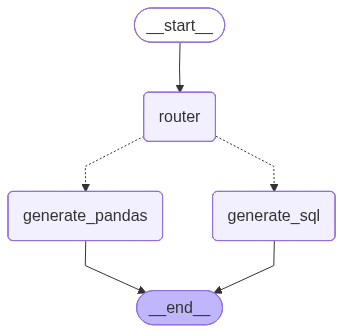

In [ ]:
from langchain_ollama import ChatOllama
from typing import TypedDict, Annotated, Literal
from langgraph.graph.message import add_messages
from langchain_core.messages import SystemMessage, HumanMessage, AnyMessage
from langgraph.graph import StateGraph, START, END
from utils import draw_graph

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    user_query: str
    domain: Literal["SQL", "Pandas"]
    generated_code: str | None
    answer: str | None
    raw_result: str | None
    error: str | None

#Router part
router_model = ChatOllama(model="phi4-mini:latest", temperature=0.0)
router_prompt = SystemMessage(
    content=(
        "Decide which domain to route the user query to.\n"
        "Options:\n"
        "- SQL: when data lives in a database (SQLite/PostgreSQL).\n"
        "- Pandas: when data is available as CSV/Parquet.\n\n"
        "Output exactly one word: SQL or Pandas."))
def router_node(state: State) -> State:
    user_message = HumanMessage(state["user_query"])
    messages = [router_prompt, *state["messages"], user_message]
    res = router_model.invoke(messages)
    raw = res.content.strip()
    domain: Literal["SQL", "Pandas"] = "SQL" if raw.lower().startswith("sql") else "Pandas"
    return {"domain": domain, "messages": [user_message, res]}

#SQL part
sql_model = ChatOllama(model="llama3.1:latest", temperature=0.1)
text_to_sql_prompt = SystemMessage("You are a helpful data analyst who generates SQL queries for users based on their questions")
def text_to_sql_node(state:State) -> State:
    messages = [text_to_sql_prompt, *state["messages"]]
    res = sql_model.invoke(messages)
    return {"generated_code": res.content,
            #update conversation history
            "messages": [res]}

#Pandas part
pandas_model = ChatOllama(model="llama3.1:latest", temperature=0.1)
text_to_pandas_prompt = SystemMessage("You are a helpful data analyst who generates Pandas queries for users based on their questions")
def text_to_pandas_node(state:State) -> State:
    messages = [text_to_pandas_prompt, *state["messages"]]
    res = pandas_model.invoke(messages)
    return {"generated_code": res.content,
            #update conversation history
            "messages": [res]}

# ----- Routing function for conditional edges -----
def route_domain(state: State) -> Literal["generate_sql", "generate_pandas"]:
    if state["domain"] == "SQL":
        return "generate_sql"
    return "generate_pandas"

#Graph part
builder = StateGraph(State)
builder.add_node("router", router_node)
builder.add_node("generate_sql", text_to_sql_node)
builder.add_node("generate_pandas", text_to_pandas_node)
builder.add_edge(START, "router")
builder.add_conditional_edges("router", route_domain)
builder.add_edge("generate_sql", END)
builder.add_edge("generate_pandas", END)

graph = builder.compile()

#Draw the graph
draw_graph(graph)

In [25]:
# Example: test a SQL-style query
initial_state = {
    "user_query": "What was the total sales amount for each year in the dataset"}

result = graph.invoke(initial_state)
print("Domain:", result["domain"])
print("Generated code:\n", result["generated_code"])

Domain: Pandas
Generated code:
  is a powerful library in Python that can be used to analyze and manipulate datasets. To calculate the total sales amount for each year, you would typically follow these steps:

1. Ensure your dataset has a column representing the date or year of each sale.
2. Convert this column into a datetime format if it's not already (this is necessary for extracting the year).
3. Group the data by year and sum up the sales amounts.

Here’s how you can achieve this with Pandas:

```python
import pandas as pd

# Assuming 'df' is your DataFrame and it has columns 'date' or 'year' and 'sales_amount'

# Step 1: Convert the date column to datetime if necessary
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])

# Step 2: Extract the year from the date
df['year'] = df['date'].dt.year

# Step 3: Group by year and sum the sales amounts
total_sales_per_year = df.groupby('year')['sales_amount'].sum().reset_index()

print(total_sales_per_year)
```

### Explan